Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital\
**Tecnología Digital VI: Inteligencia Artificial**

Importamos librerias

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

Definimos una transformación simple para imágenes RGB

In [12]:
transform = transforms.Compose([
    transforms.ToTensor() #ToTensor ya normaliza a valores en [0,1]
])

Para esta prueba vamos a utilizar el dataset MNIST

In [49]:
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
targets_ = train_set.targets

train_idx, val_idx = train_test_split(np.arange(len(targets_)), test_size = 0.2, stratify = targets_)
train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)

train_loader = DataLoader(train_set, sampler=train_sampler, batch_size=64)
val_loader = DataLoader(train_set, sampler=val_sampler, batch_size=64)
test_loader = DataLoader(test_set, batch_size=64)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Arquitectura del Autoencoder

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.enc_conv1 = nn.Conv2d(1, 16, 3, padding=1, stride=1)  # entrada: 28x28x1 salida: 28x28x16
        self.pool1 = nn.MaxPool2d(2, 2)  # salida: 14x14x16
        self.enc_conv2 = nn.Conv2d(16, 32, 3, padding=1, stride=1)  # salida: 14x14x32
        self.pool2 = nn.MaxPool2d(2, 2)  # salida: 7x7x32
        self.enc_conv3 = nn.Conv2d(32, 32, 3, padding=1, stride=1)  # salida: 7x7x32

        # Decoder
        self.dec_conv1 = nn.ConvTranspose2d(32, 32, 2, stride=2)  # entrada: 7x7x32 salida: 14x14x32
        self.dec_conv2 = nn.ConvTranspose2d(32, 16, 2, stride=2)  # entrada: 14x14x32 salida: 28x28x16
        self.dec_conv3 = nn.ConvTranspose2d(16, 1, 3, padding=1)  # entrada: 28x28x16 salida: 28x28x1

    def forward_encoder(self, x):
        x = F.relu(self.enc_conv1(x))
        x = self.pool1(x)
        x = F.relu(self.enc_conv2(x))
        x = self.pool2(x)
        x = F.relu(self.enc_conv3(x))
        return x

    def forward_decoder(self, x):
        x = F.relu(self.dec_conv1(x))
        x = F.relu(self.dec_conv2(x))
        x = torch.sigmoid(self.dec_conv3(x))
        return x

    def forward(self, x):
        x = self.forward_encoder(x)
        x = self.forward_decoder(x)
        return x

autoencoder = Autoencoder().to(device)

Definimos función de pérdida y optimizador

In [31]:
criterion = nn.MSELoss().to(device)
optimizer = torch.optim.SGD(autoencoder.parameters(), lr=0.01, momentum=0.9)

Entrenamos

In [32]:
num_epochs = 20

for epoch in range(num_epochs):
  train_loss = []
  val_loss = []



  for data in train_loader:
    imgs, labels = data
    imgs = imgs.to(device)
    outputs = autoencoder(imgs)
    loss = criterion(outputs, imgs) # Comparar la imagen reconstruida con la original
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss.append(loss.item() * imgs.size(0))


  with torch.no_grad():
    for data_val in val_loader:
      imgs_val, labels_val = data_val
      imgs_val = imgs_val.to(device)
      outputs_val = autoencoder(imgs_val)
      loss_val = criterion(outputs_val, imgs_val) # Comparar la imagen reconstruida con la original
      val_loss.append(loss_val.item() * imgs_val.size(0))



  print(f'Epoch: {epoch+1}, Train Loss: {np.mean(train_loss):.4f}, Val Loss: {np.mean(val_loss):.4f}')

Epoch: 1, Train Loss: 6.3584, Val Loss: 6.1438
Epoch: 2, Train Loss: 6.1458, Val Loss: 6.1070
Epoch: 3, Train Loss: 6.1121, Val Loss: 6.0757
Epoch: 4, Train Loss: 6.0793, Val Loss: 6.0404
Epoch: 5, Train Loss: 6.0337, Val Loss: 5.9735
Epoch: 6, Train Loss: 5.7826, Val Loss: 4.8419
Epoch: 7, Train Loss: 2.6016, Val Loss: 1.7302
Epoch: 8, Train Loss: 1.4166, Val Loss: 1.1318
Epoch: 9, Train Loss: 0.9545, Val Loss: 0.8290
Epoch: 10, Train Loss: 0.7562, Val Loss: 0.6937
Epoch: 11, Train Loss: 0.6458, Val Loss: 0.6013
Epoch: 12, Train Loss: 0.5680, Val Loss: 0.5355
Epoch: 13, Train Loss: 0.5129, Val Loss: 0.4914
Epoch: 14, Train Loss: 0.4742, Val Loss: 0.4573
Epoch: 15, Train Loss: 0.4458, Val Loss: 0.4335
Epoch: 16, Train Loss: 0.4240, Val Loss: 0.4133
Epoch: 17, Train Loss: 0.4062, Val Loss: 0.3975
Epoch: 18, Train Loss: 0.3913, Val Loss: 0.3836
Epoch: 19, Train Loss: 0.3785, Val Loss: 0.3719
Epoch: 20, Train Loss: 0.3672, Val Loss: 0.3612


Observemos los resultados con algunas imágenes de train

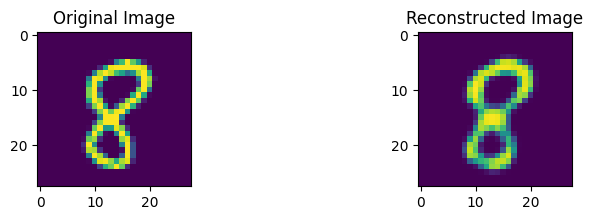

torch.Size([32, 7, 7])
tensor([[0.0662, 0.0673, 0.1459,  ..., 1.1744, 0.4074, 0.1345]],
       device='cuda:0')


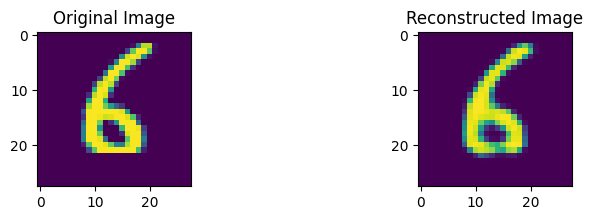

torch.Size([32, 7, 7])
tensor([[0.1205, 0.1629, 0.0140,  ..., 0.8463, 0.4695, 0.1200]],
       device='cuda:0')


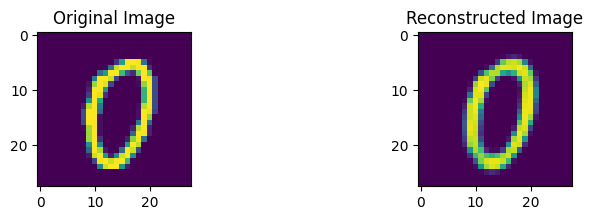

torch.Size([32, 7, 7])
tensor([[0.0979, 0.1608, 0.0219,  ..., 1.0491, 0.4381, 0.1321]],
       device='cuda:0')


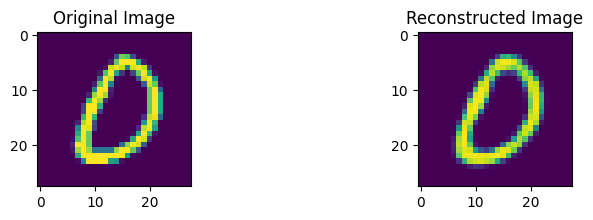

torch.Size([32, 7, 7])
tensor([[0.1260, 0.1762, 0.1620,  ..., 0.6841, 0.4586, 0.1614]],
       device='cuda:0')


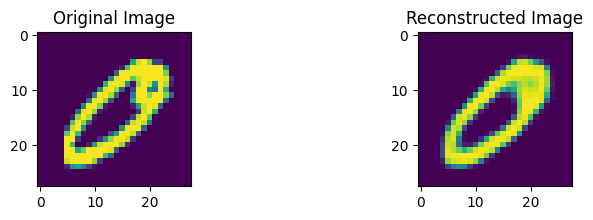

torch.Size([32, 7, 7])
tensor([[0.1333, 0.1196, 0.0734,  ..., 0.4021, 0.4048, 0.1361]],
       device='cuda:0')


In [33]:
train_iter = iter(train_loader)
imgs, labels = next(train_iter)
imgs = imgs.to(device)

with torch.no_grad():
    outputs = autoencoder(imgs)
    latent_space = autoencoder.forward_encoder(imgs)

imgs = imgs.cpu().numpy()
outputs = outputs.cpu().numpy()

num_imgs = 5
for i in range(num_imgs):
    original_image = np.transpose(imgs[i], (1, 2, 0))
    reconstructed_image = np.transpose(outputs[i], (1, 2, 0))


    # Mostrar la imagen original
    plt.figure(figsize=(9, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image, interpolation='none')
    plt.title('Original Image')

    # Mostrar la imagen reconstruida
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_image, interpolation='none')
    plt.title('Reconstructed Image')

    plt.show()

    print(latent_space[i].shape)
    print(latent_space[i].view(1, -1))


Observemos los resultados con algunas imágenes de test

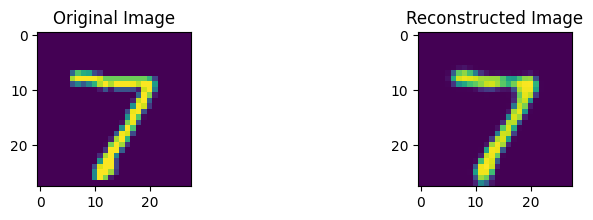

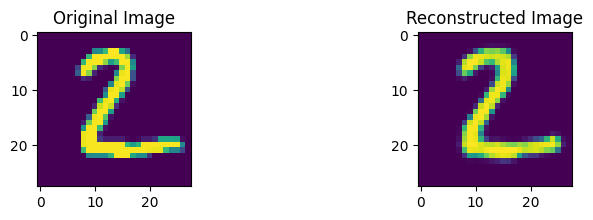

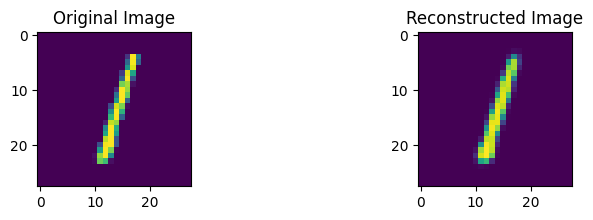

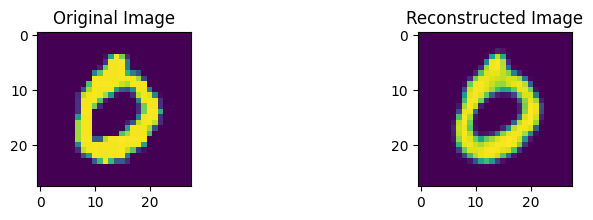

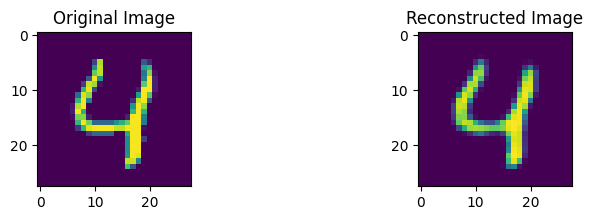

In [34]:
test_iter = iter(test_loader)
imgs, labels = next(test_iter)
imgs = imgs.to(device)

with torch.no_grad():
    outputs = autoencoder(imgs)

imgs = imgs.cpu().numpy()
outputs = outputs.cpu().numpy()

num_imgs = 5
for i in range(num_imgs):
    original_image = np.transpose(imgs[i], (1, 2, 0))
    reconstructed_image = np.transpose(outputs[i], (1, 2, 0))


    # Mostrar la imagen original
    plt.figure(figsize=(9, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image, interpolation='none')
    plt.title('Original Image')

    # Mostrar la imagen reconstruida
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_image, interpolation='none')
    plt.title('Reconstructed Image')

    plt.show()

### ¿Y si restringimos más la red?

In [50]:
class Autoencoder2(nn.Module):
    def __init__(self):
        super(Autoencoder2, self).__init__()

        # Encoder
        self.enc_conv1 = nn.Conv2d(1, 16, 3, padding=1, stride=1)  # entrada: 28x28x1 salida: 28x28x16
        self.pool1 = nn.MaxPool2d(2, 2)  # salida: 14x14x16
        self.enc_conv2 = nn.Conv2d(16, 16, 3, padding=1, stride=1)  # salida: 14x14x16
        self.pool2 = nn.MaxPool2d(2, 2)  # salida: 7x7x16
        self.enc_conv3 = nn.Conv2d(16, 1, 3, padding=1, stride=1)  # salida: 7x7x1

        # Decoder
        self.dec_conv1 = nn.ConvTranspose2d(1, 16, 2, stride=2)       # salida: 14x14x16
        self.dec_conv2 = nn.ConvTranspose2d(16, 16, 2, stride=2)      # salida: 28x28x16
        self.dec_conv3 = nn.Conv2d(16, 1, 3, padding=1)               # salida: 28x28x1

    def forward_encoder(self, x):
        x = F.relu(self.enc_conv1(x))
        x = self.pool1(x)
        x = F.relu(self.enc_conv2(x))
        x = self.pool2(x)
        x = F.relu(self.enc_conv3(x))
        return x

    def forward_decoder(self, x):
        x = F.relu(self.dec_conv1(x))
        x = F.relu(self.dec_conv2(x))
        x = torch.sigmoid(self.dec_conv3(x))  # salida: 28x28x1, aplicamos sigmoid para tener valores entre [0, 1]
        return x

    def forward(self, x):
        x = self.forward_encoder(x)
        x = self.forward_decoder(x)
        return x

autoencoder2 = Autoencoder2().to(device)

In [51]:
criterion = nn.MSELoss().to(device)
optimizer = torch.optim.SGD(autoencoder2.parameters(), lr=0.02, momentum=0.9)

In [52]:
num_epochs = 50

for epoch in range(num_epochs):
  train_loss = []
  val_loss = []

  for data in train_loader:
    imgs, labels = data
    imgs = imgs.to(device)
    outputs = autoencoder2(imgs)
    loss = criterion(outputs, imgs) # Comparar la imagen reconstruida con la original
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss.append(loss.item() * imgs.size(0))


  with torch.no_grad():
    for data_val in val_loader:
      imgs_val, labels_val = data_val
      imgs_val = imgs_val.to(device)
      outputs_val = autoencoder2(imgs_val)
      loss_val = criterion(outputs_val, imgs_val) # Comparar la imagen reconstruida con la original
      val_loss.append(loss_val.item() * imgs_val.size(0))




  print(f'Epoch: {epoch+1}, Train Loss: {np.mean(train_loss):.4f}, Val Loss: {np.mean(val_loss):.4f}')

Epoch: 1, Train Loss: 6.4137, Val Loss: 6.1438
Epoch: 2, Train Loss: 6.1007, Val Loss: 6.1091
Epoch: 3, Train Loss: 6.0680, Val Loss: 6.0760
Epoch: 4, Train Loss: 6.0336, Val Loss: 6.0402
Epoch: 5, Train Loss: 5.9991, Val Loss: 6.0073
Epoch: 6, Train Loss: 5.9700, Val Loss: 5.9818
Epoch: 7, Train Loss: 5.9482, Val Loss: 5.9635
Epoch: 8, Train Loss: 5.9318, Val Loss: 5.9478
Epoch: 9, Train Loss: 5.9125, Val Loss: 5.9137
Epoch: 10, Train Loss: 4.4094, Val Loss: 2.2110
Epoch: 11, Train Loss: 1.9741, Val Loss: 1.8217
Epoch: 12, Train Loss: 1.7677, Val Loss: 1.7246
Epoch: 13, Train Loss: 1.6869, Val Loss: 1.6507
Epoch: 14, Train Loss: 1.6272, Val Loss: 1.6016
Epoch: 15, Train Loss: 1.5826, Val Loss: 1.5625
Epoch: 16, Train Loss: 1.5480, Val Loss: 1.5304
Epoch: 17, Train Loss: 1.5196, Val Loss: 1.5069
Epoch: 18, Train Loss: 1.4998, Val Loss: 1.4903
Epoch: 19, Train Loss: 1.4852, Val Loss: 1.4771
Epoch: 20, Train Loss: 1.4736, Val Loss: 1.4663
Epoch: 21, Train Loss: 1.4643, Val Loss: 1.4578
E

Visualizamos en imágenes de train

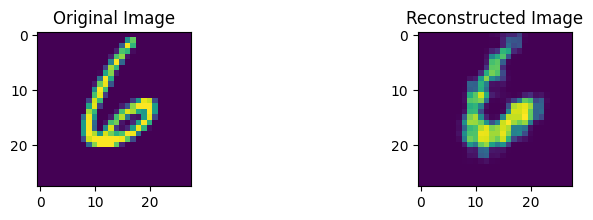

torch.Size([1, 7, 7])
tensor([[1.0329, 1.1145, 0.7224, 3.2399, 5.6701, 0.4349, 1.2289, 1.0402, 1.2049,
         1.4521, 7.6080, 1.5847, 0.8993, 1.2536, 1.1547, 0.5208, 5.9065, 4.1513,
         1.7423, 2.7522, 1.1079, 1.1782, 0.9168, 7.2506, 2.1456, 8.5351, 5.9830,
         0.5067, 0.7680, 2.6939, 7.4728, 8.0945, 6.4643, 2.3851, 1.0090, 1.0723,
         0.8436, 4.4475, 4.3401, 1.6926, 0.7893, 1.3430, 1.2447, 1.3166, 0.7967,
         0.9012, 1.2187, 1.2092, 1.5334]], device='cuda:0')


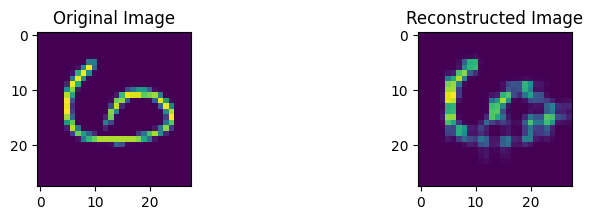

torch.Size([1, 7, 7])
tensor([[1.1087, 0.9725, 0.5314, 0.8798, 1.0508, 1.0145, 1.2212, 1.0590, 2.7078,
         6.9274, 0.4421, 0.6219, 0.7050, 1.1165, 0.3570, 7.5574, 1.7158, 2.7326,
         5.5038, 4.2536, 1.0150, 0.8458, 6.8857, 0.0357, 7.1285, 2.0584, 4.0924,
         4.6997, 0.4582, 5.3292, 4.3803, 3.0904, 3.6248, 5.1690, 2.8399, 1.0941,
         1.3232, 3.0897, 3.5398, 2.9972, 1.4298, 0.8999, 1.2507, 1.1950, 1.0480,
         1.0028, 1.0796, 1.1869, 1.5680]], device='cuda:0')


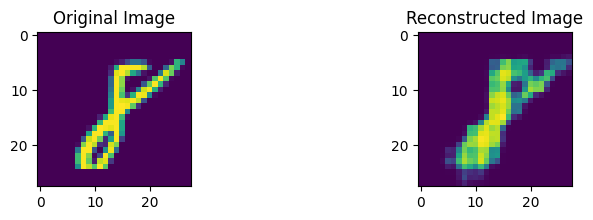

torch.Size([1, 7, 7])
tensor([[1.0290, 1.0166, 1.1919, 0.3944, 0.2349, 0.5211, 0.9676, 1.0522, 1.0826,
         0.5103, 5.8851, 7.0479, 3.2032, 6.2748, 1.0464, 1.1817, 0.3536, 7.5494,
         4.5362, 7.9411, 1.4463, 1.0629, 1.2465, 0.7377, 8.4981, 6.2342, 1.0308,
         1.0528, 1.2715, 0.7595, 7.4455, 8.4739, 1.4556, 1.1041, 1.2261, 0.7030,
         4.8047, 7.5383, 6.7539, 0.4915, 1.2147, 1.2334, 0.7422, 3.0483, 4.9095,
         2.3527, 1.0215, 1.1649, 1.5492]], device='cuda:0')


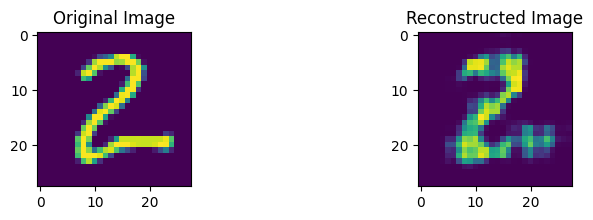

torch.Size([1, 7, 7])
tensor([[1.1470, 1.2011, 0.5034, 2.8017, 2.7317, 0.4451, 1.2681, 1.0029, 1.7117,
         8.8289, 5.9452, 8.3170, 1.2501, 1.1727, 0.6744, 3.2597, 2.2394, 3.0373,
         8.9659, 0.4885, 1.3210, 1.2436, 0.0000, 5.4427, 8.1756, 1.6205, 0.7751,
         0.8361, 0.8428, 3.4191, 7.2316, 1.9394, 4.6831, 4.9959, 3.7146, 0.3296,
         4.9042, 7.6974, 7.0657, 4.0686, 5.2321, 2.4012, 1.1882, 1.4030, 2.4090,
         0.0556, 0.7970, 0.8543, 1.3545]], device='cuda:0')


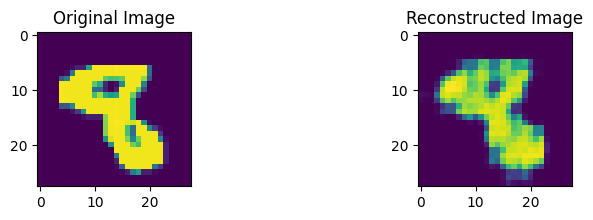

torch.Size([1, 7, 7])
tensor([[ 1.2038,  0.9573,  0.3896,  0.0000,  0.0000,  0.5076,  1.2469,  0.4539,
          3.2201,  6.3742,  6.5142,  7.2988,  3.6699,  0.7079,  3.1105, 10.9361,
          8.0538,  5.3725,  9.4532,  1.8110,  1.2792,  2.4851,  5.8315,  8.6059,
          9.4755,  5.1764,  0.6823,  1.2901,  0.9774,  0.3390,  1.9903,  9.5846,
          8.0435,  6.6409,  0.2902,  1.1321,  1.2221,  0.8124,  6.3642,  9.5787,
          9.9939,  0.6169,  1.1977,  1.2778,  0.8158,  2.7656,  5.4451,  3.3166,
          0.9184]], device='cuda:0')


In [53]:
import matplotlib.pyplot as plt

# Cambiar el modelo a modo de evaluación
autoencoder2.eval()

train_iter = iter(train_loader)
imgs, labels = next(train_iter)
imgs = imgs.to(device)

with torch.no_grad():
    outputs = autoencoder2(imgs)
    latent_space = autoencoder2.forward_encoder(imgs)

imgs = imgs.cpu().numpy()
outputs = outputs.cpu().numpy()

num_imgs = 5
for i in range(num_imgs):
    original_image = np.transpose(imgs[i], (1, 2, 0))
    reconstructed_image = np.transpose(outputs[i], (1, 2, 0))


    # Mostrar la imagen original
    plt.figure(figsize=(9, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image, interpolation='none')
    plt.title('Original Image')

    # Mostrar la imagen reconstruida
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_image, interpolation='none')
    plt.title('Reconstructed Image')

    plt.show()

    print(latent_space[i].shape)
    print(latent_space[i].view(1, -1))


Visualizamos en imágenes de test

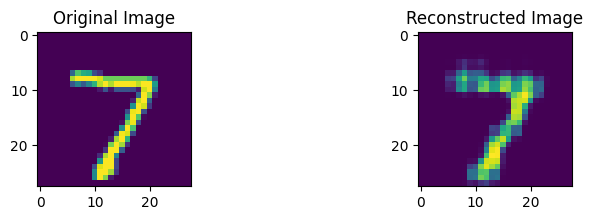

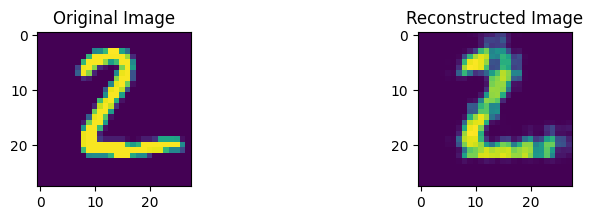

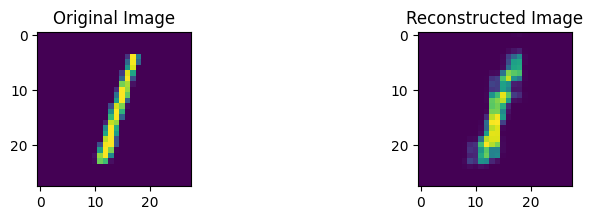

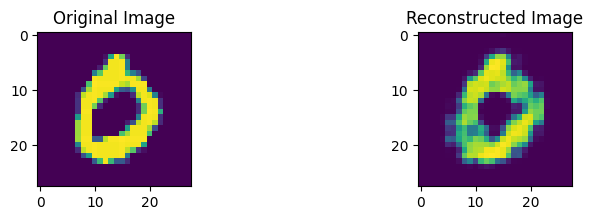

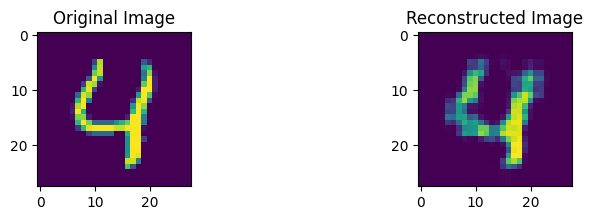

In [54]:

test_iter = iter(test_loader)
imgs, labels = next(test_iter)
imgs = imgs.to(device)

with torch.no_grad():
    outputs = autoencoder2(imgs)

imgs = imgs.cpu().numpy()
outputs = outputs.cpu().numpy()

num_imgs = 5
for i in range(num_imgs):
    original_image = np.transpose(imgs[i], (1, 2, 0))
    reconstructed_image = np.transpose(outputs[i], (1, 2, 0))


    # Mostrar la imagen original
    plt.figure(figsize=(9, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image, interpolation='none')
    plt.title('Original Image')

    # Mostrar la imagen reconstruida
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_image, interpolation='none')
    plt.title('Reconstructed Image')

    plt.show()

## 2da parte - jugando con el espacio latente

torch.Size([20, 1, 7, 7])


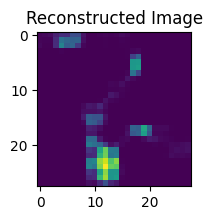

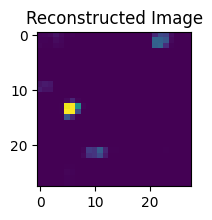

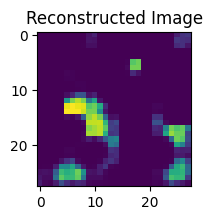

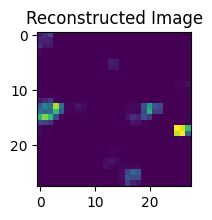

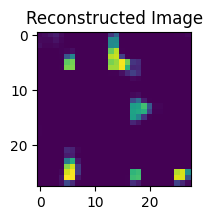

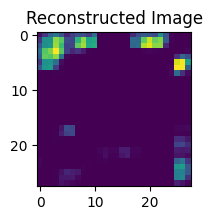

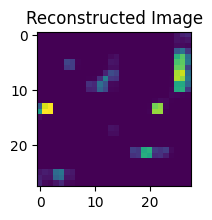

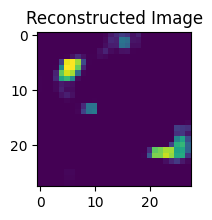

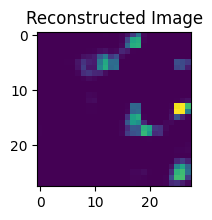

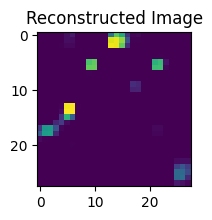

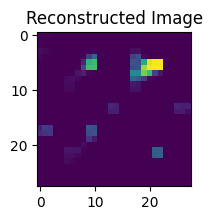

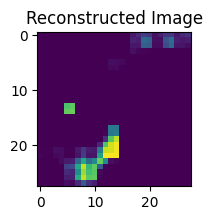

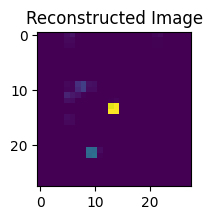

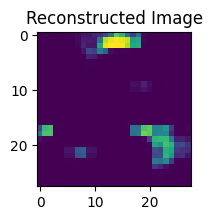

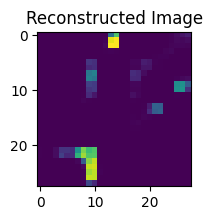

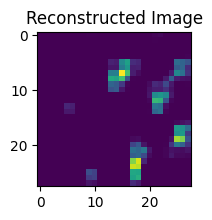

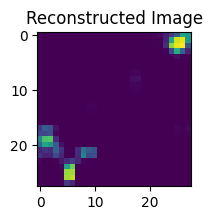

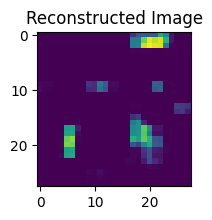

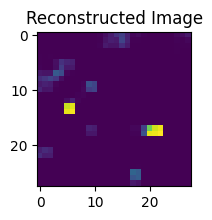

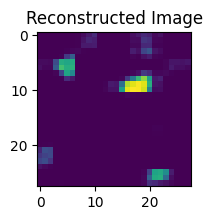

In [64]:
# Probemos valores random en el espacio latente y ver qué imagen reconstruye

latent_space = torch.randn(20, 1, 7, 7).to(device) * 4 # 5 imágenes, 1 canal, 7x7
print(latent_space.shape)

with torch.no_grad():
    outputs = autoencoder2.forward_decoder(latent_space)

outputs = outputs.cpu().numpy()

num_imgs = 20
for i in range(num_imgs):
    reconstructed_image = np.transpose(outputs[i], (1, 2, 0))

    # Desnormalizar las imágenes
    reconstructed_image = reconstructed_image * 0.5 + 0.5

    # Asegurarse de que los valores estén entre 0 y 1
    reconstructed_image = np.clip(reconstructed_image, 0, 1)

    # Mostrar la imagen reconstruida
    plt.figure(figsize=(9, 2))
    plt.imshow(reconstructed_image, interpolation='none')
    plt.title('Reconstructed Image')

    plt.show()


Probemos ahora partir del espacio latente de una imagen real y luego variar aleatoriamente estos valores.

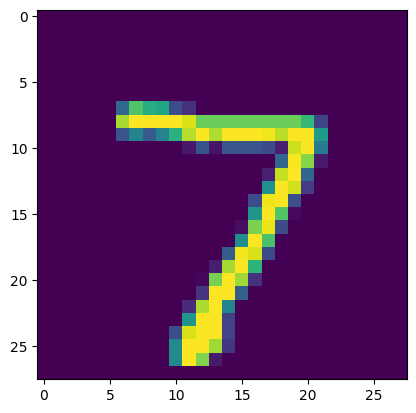

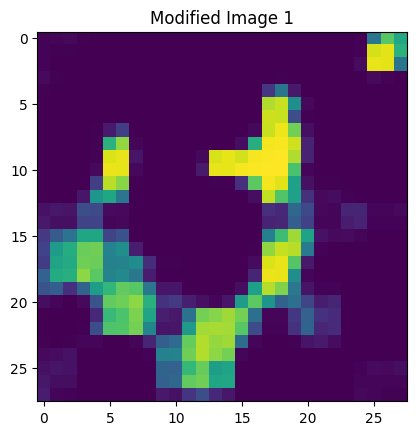

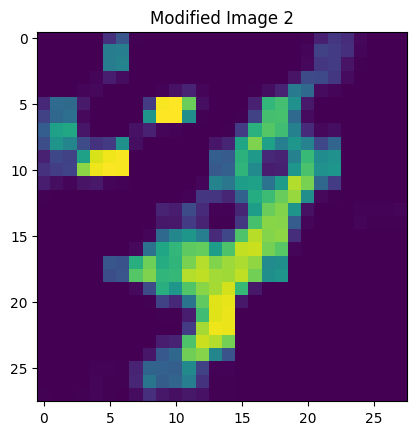

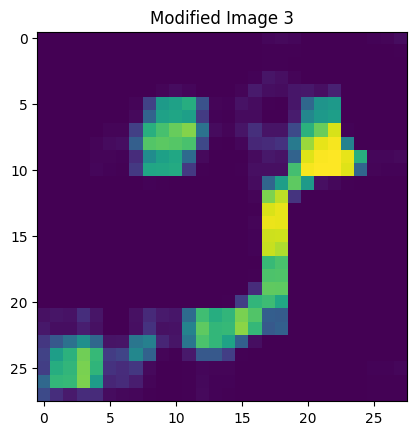

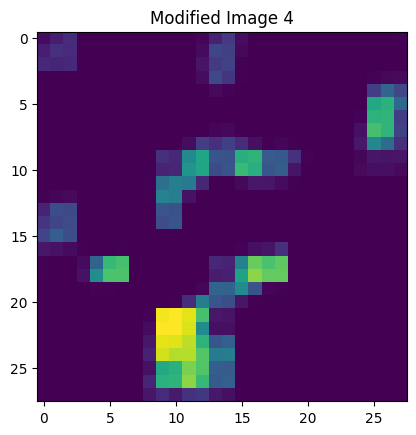

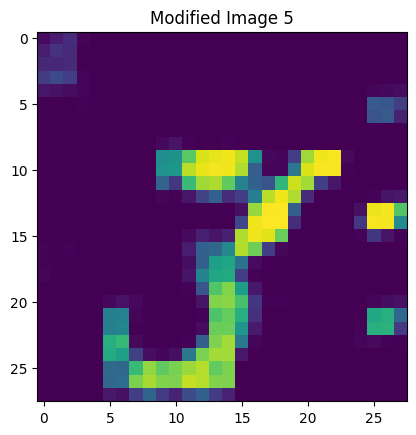

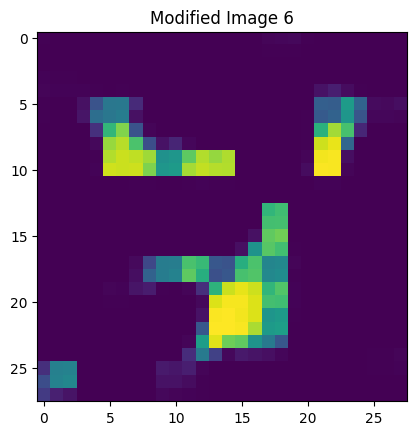

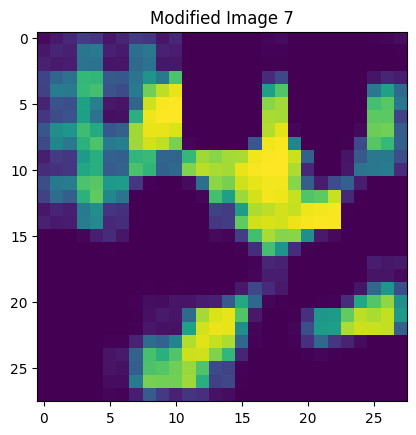

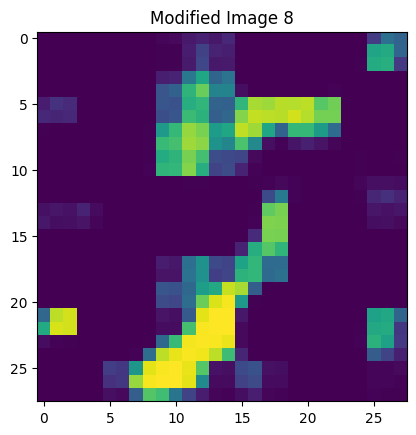

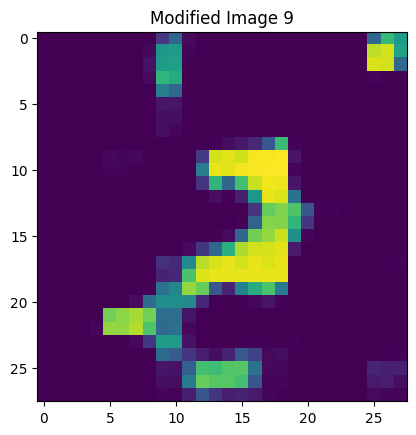

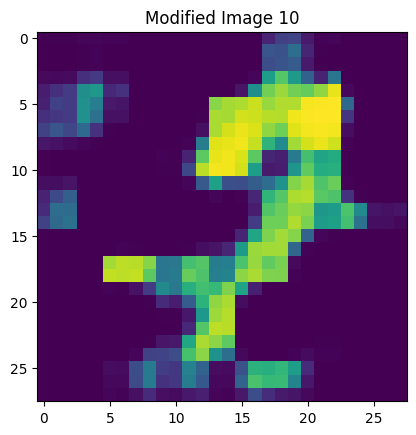

In [63]:
# Probemos ahora partir del espacio latente de un numero y modificar sus valores de forma random
imgs = next(iter(test_loader))[0]
imgs = imgs.cpu()

original_image = np.transpose(imgs.numpy()[0], (1, 2, 0))
plt.imshow(original_image, interpolation='none')
plt.show()


with torch.no_grad():
    latent_spaces = autoencoder2.forward_encoder(imgs.to(device))
    original_latent = latent_spaces[0]

    for i in range(10):
        # Generar ruido aleatorio
        noise = torch.randn_like(original_latent) * 4  # Ajusta la magnitud del ruido según necesites

        # Modificar el vector latente original con el ruido
        modified_latent = original_latent + noise

        # Decodificar el vector latente modificado para obtener una imagen
        decoded_image = autoencoder2.forward_decoder(modified_latent.unsqueeze(0)).cpu()

        # Preparar y mostrar la imagen
        decoded_image_np = np.transpose(decoded_image.numpy()[0], (1, 2, 0))
        plt.imshow(decoded_image_np, interpolation='none')
        plt.title(f"Modified Image {i+1}")
        plt.show()